In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- Configuration ---
PROJECT_ROOT_PATH = r"C:\Users\Enjoy\OneDrive\Desktop\STData"
MODELS_DIR = os.path.join(PROJECT_ROOT_PATH, "models")
FEATURE_DATASET_PATH = os.path.join(PROJECT_ROOT_PATH, "final_features.csv")

# --- Matplotlib settings for better plots ---
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

print("Libraries imported and paths configured.")

Libraries imported and paths configured.


In [3]:
print("Loading feature dataset")
df = pd.read_csv(FEATURE_DATASET_PATH)
df.dropna(inplace=True)
df['student_id'] = df['trial_id'].apply(lambda x: x.split('_')[0]) # Assuming 'S01_T1' format

# --- Calculate Baseline Cross-Participant MAE ---
print("\n Evaluating Cross-Participant Model (Baseline)")
X = df.drop(columns=['trial_id', 'response_time', 'student_id'])
y = df['response_time']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_cross = joblib.load(os.path.join(MODELS_DIR, "scaler.pkl"))
gb_model_cross = joblib.load(os.path.join(MODELS_DIR, "gb_model.pkl"))

X_test_scaled = scaler_cross.transform(X_test)
cross_participant_predictions = gb_model_cross.predict(X_test_scaled)
cross_participant_mae = mean_absolute_error(y_test, cross_participant_predictions)

print(f"Baseline Cross-Participant Model MAE: {cross_participant_mae:.4f}")

Loading feature dataset

 Evaluating Cross-Participant Model (Baseline)
Baseline Cross-Participant Model MAE: 0.2174


In [4]:
print("--- Training a specialized model for each participant ---")
per_participant_results = {}
student_ids = df['student_id'].unique()

for student_id in student_ids:
    student_df = df[df['student_id'] == student_id]
    if len(student_df) < 10: 
        continue

    X_student = student_df.drop(columns=['trial_id', 'response_time', 'student_id'])
    y_student = student_df['response_time']
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_student, y_student, test_size=0.25, random_state=42)
    
    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled = scaler_s.transform(X_test_s)
    
    model_s = XGBRegressor(n_estimators=100, random_state=42)
    model_s.fit(X_train_s_scaled, y_train_s)
    
    predictions_s = model_s.predict(X_test_s_scaled)
    mae_s = mean_absolute_error(y_test_s, predictions_s)
    per_participant_results[student_id] = mae_s
    print(f"  - Student {student_id} MAE: {mae_s:.4f}")

average_per_participant_mae = np.mean(list(per_participant_results.values()))
print(f"\n Average Per-Participant MAE: {average_per_participant_mae:.4f}")

--- Training a specialized model for each participant ---
  - Student student MAE: 1.0177

 Average Per-Participant MAE: 1.0177


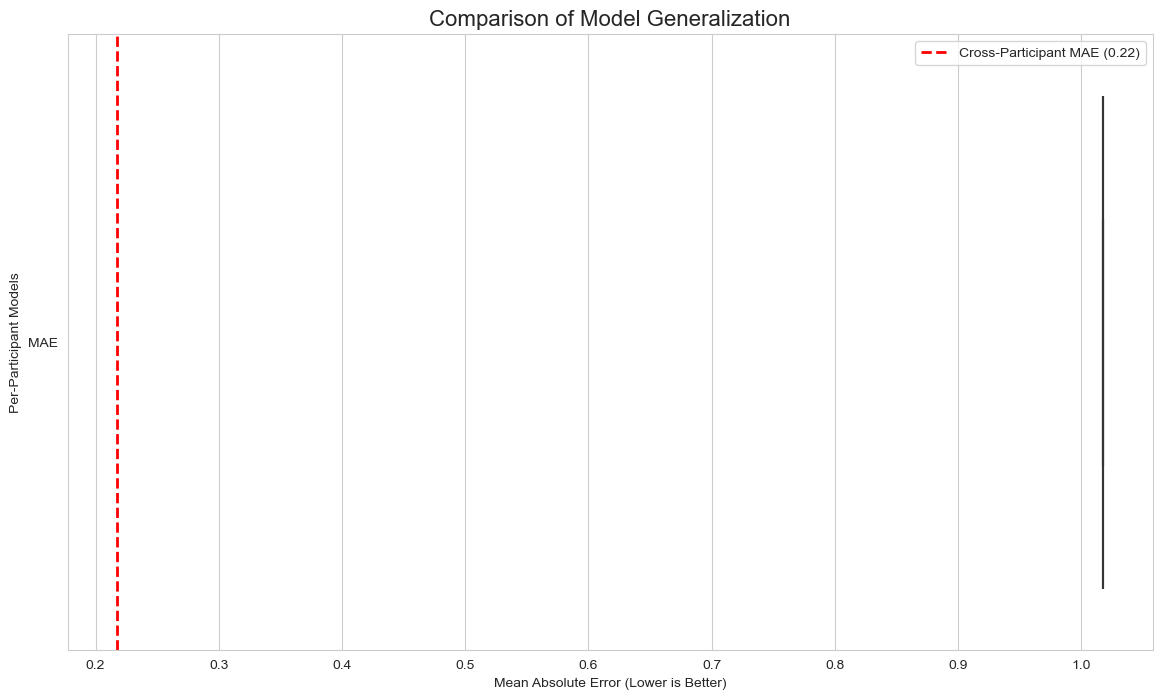

--- Conclusion ---
The cross-participant model performed better or similarly.
This suggests that physiological responses are generalizable across participants.


In [5]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=pd.DataFrame(per_participant_results, index=['MAE']).T, orient='h', palette='viridis')
plt.axvline(x=cross_participant_mae, color='r', linestyle='--', linewidth=2, label=f'Cross-Participant MAE ({cross_participant_mae:.2f})')
plt.title('Comparison of Model Generalization', fontsize=16)
plt.xlabel('Mean Absolute Error (Lower is Better)')
plt.ylabel('Per-Participant Models')
plt.legend()
plt.show()

# --- Conclusion ---
print("--- Conclusion ---")
if average_per_participant_mae < cross_participant_mae:
    print("Per-participant models performed better on average.")
    print("This suggests that individual physiological patterns are significant and models benefit from specialization.")
else:
    print("The cross-participant model performed better or similarly.")
    print("This suggests that physiological responses are generalizable across participants.")

In [7]:
print("--- Applying PCA to find optimal number of components ---")
X_train_scaled = scaler_cross.fit_transform(X_train_s) # Use the full training set
X_test_scaled = scaler_cross.transform(X_test)

pca_explorer = PCA(n_components=0.95) # Retain 95% of variance
X_train_pca = pca_explorer.fit_transform(X_train_scaled)
n_components = pca_explorer.n_components_

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Reduced features needed for 95% variance: {n_components}")

--- Applying PCA to find optimal number of components ---
Original number of features: 41
Reduced features needed for 95% variance: 13


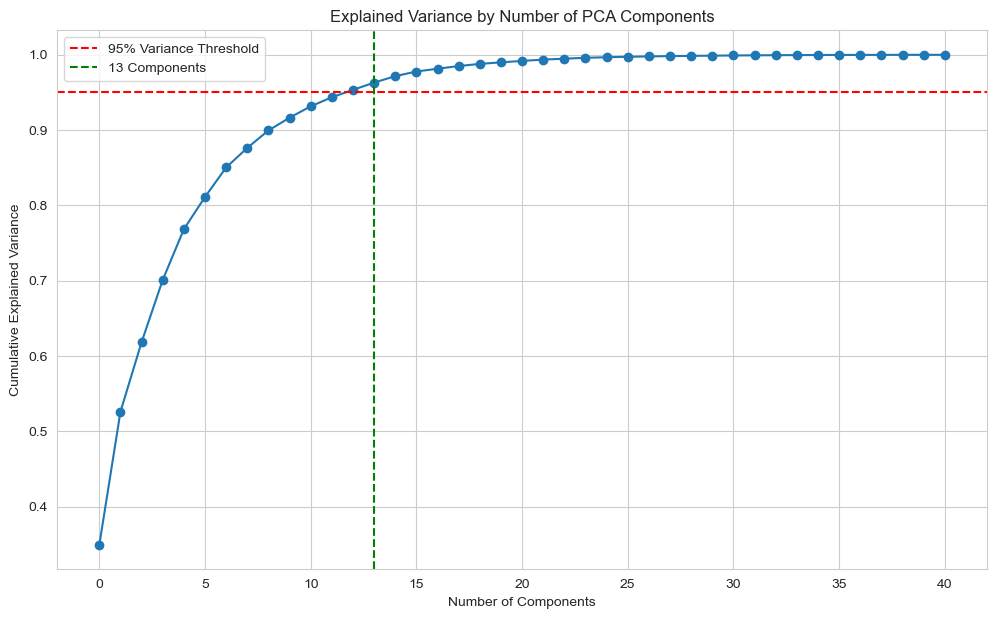

In [8]:
plt.figure(figsize=(12, 7))
plt.plot(np.cumsum(PCA().fit(X_train_scaled).explained_variance_ratio_), marker='o', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Number of PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} Components')
plt.legend()
plt.show()

--- Training XGBoost model on PCA-transformed features ---

--- PCA Performance Summary ---


,MAE
Model,
Original (37 Features),0.217443
PCA (13 Features),2.270795


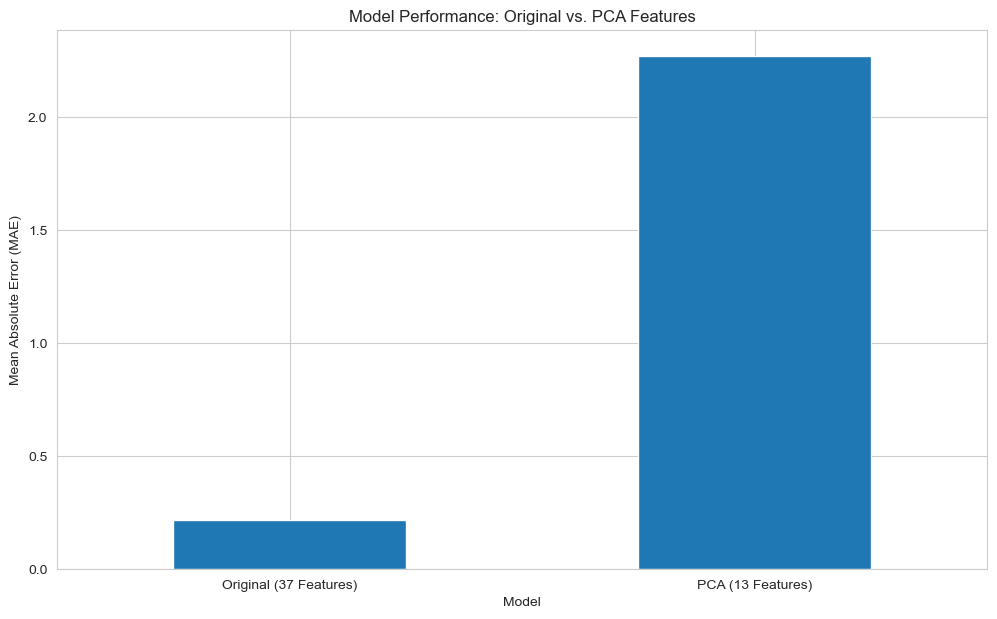

In [10]:
print("--- Training XGBoost model on PCA-transformed features ---")
X_test_pca = pca_explorer.transform(X_test_scaled)

xgb_pca = XGBRegressor(n_estimators=100, random_state=42)
xgb_pca.fit(X_train_pca, y_train_s)

predictions_pca = xgb_pca.predict(X_test_pca)
mae_pca = mean_absolute_error(y_test, predictions_pca)

# --- Comparison ---
results_df = pd.DataFrame({
    'Model': ['Original (37 Features)', f'PCA ({n_components} Features)'],
    'MAE': [cross_participant_mae, mae_pca]
}).set_index('Model')

print("\n--- PCA Performance Summary ---")
display(results_df)

results_df.plot(kind='bar', legend=None)
plt.title('Model Performance: Original vs. PCA Features')
plt.ylabel('Mean Absolute Error (MAE)')
plt.xticks(rotation=0)
plt.show()

In [11]:
print("--- Training models on individual sensor modalities ---")
eeg_cols = [col for col in df.columns if 'eeg_' in col]
eye_cols = [col for col in df.columns if 'eye_' in col]

# --- EEG-only Model ---
X_train_eeg, X_test_eeg, y_train, y_test = train_test_split(df[eeg_cols], y, test_size=0.2, random_state=42)
scaler_eeg = StandardScaler().fit(X_train_eeg)
model_eeg = XGBRegressor(n_estimators=100, random_state=42).fit(scaler_eeg.transform(X_train_eeg), y_train)
mae_eeg = mean_absolute_error(y_test, model_eeg.predict(scaler_eeg.transform(X_test_eeg)))
print(f"EEG-only Model MAE: {mae_eeg:.4f}")

# --- Eye-tracking-only Model ---
X_train_eye, X_test_eye, _, _ = train_test_split(df[eye_cols], y, test_size=0.2, random_state=42)
scaler_eye = StandardScaler().fit(X_train_eye)
model_eye = XGBRegressor(n_estimators=100, random_state=42).fit(scaler_eye.transform(X_train_eye), y_train)
mae_eye = mean_absolute_error(y_test, model_eye.predict(scaler_eye.transform(X_test_eye)))
print(f"Eye-tracking-only Model MAE: {mae_eye:.4f}")

--- Training models on individual sensor modalities ---
EEG-only Model MAE: 2.9943
Eye-tracking-only Model MAE: 0.5483


Modality Performance Summary


,MAE
Model,
EEG Features Only,2.994331
Eye-Tracking Features Only,0.548301
Original (All Features),0.217443


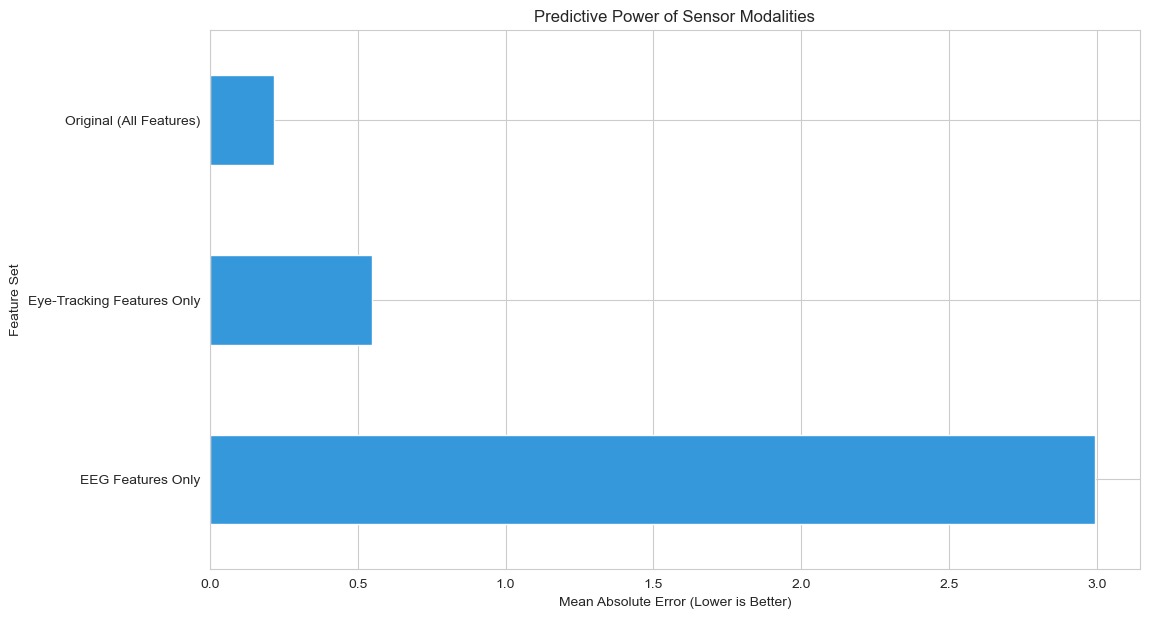

In [12]:
modality_results = pd.DataFrame({
    'Model': ['EEG Features Only', 'Eye-Tracking Features Only', 'Original (All Features)'],
    'MAE': [mae_eeg, mae_eye, cross_participant_mae]
}).set_index('Model')

print("Modality Performance Summary")
display(modality_results)

modality_results.plot(kind='barh', legend=None, color=['#3498db', '#9b59b6', '#2ecc71'])
plt.title('Predictive Power of Sensor Modalities')
plt.xlabel('Mean Absolute Error (Lower is Better)')
plt.ylabel('Feature Set')
plt.show()

In [17]:
# Generalization Summary
print("\n1. Generalization Performance")
print("-" * 35)
print(f"Cross-Participant MAE (one model for all): {cross_participant_mae:.4f}")
print(f"Average Per-Participant MAE (specialized): {average_per_participant_mae:.4f}")
if average_per_participant_mae < cross_participant_mae:
    print("Conclusion: Specialized, per-participant models are more accurate.")
else:
    print("Conclusion: The general, cross-participant model is more robust.")



1. Generalization Performance
-----------------------------------
Cross-Participant MAE (one model for all): 0.2174
Average Per-Participant MAE (specialized): 1.0177
Conclusion: The general, cross-participant model is more robust.


In [16]:
# PCA Summary
print("\n2. Dimensionality Reduction (PCA)")
print("-" * 35)
print(f"Original feature count:    {X.shape[1]}")
print(f"PCA feature count (95% var): {n_components}")
print(f"\nOriginal Model MAE:        {cross_participant_mae:.4f}")
print(f"PCA-based Model MAE:         {mae_pca:.4f}")
if mae_pca < cross_participant_mae * 1.05:
    print("Conclusion: PCA significantly reduced features with minimal accuracy loss.")
else:
    print("Conclusion: The original feature set is superior for model performance.")



2. Dimensionality Reduction (PCA)
-----------------------------------
Original feature count:    41
PCA feature count (95% var): 13

Original Model MAE:        0.2174
PCA-based Model MAE:         2.2708
Conclusion: The original feature set is superior for model performance.


In [19]:
# Modality Summary
print("\n3. Sensor Modality (Ablation) Analysis")
print("-" * 35)
print(f"Original Model MAE (All Features): {cross_participant_mae:.4f}")
print(f"EEG-only Model MAE:                {mae_eeg:.4f}")
print(f"Eye-tracking-only Model MAE:       {mae_eye:.4f}")
if mae_eeg < cross_participant_mae and mae_eye < cross_participant_mae:
    print("Conclusion: Both modalities are highly predictive; EEG is stronger.")
else:
    print("Conclusion: Combining EEG and Eye-tracking is crucial for best performance.")



3. Sensor Modality (Ablation) Analysis
-----------------------------------
Original Model MAE (All Features): 0.2174
EEG-only Model MAE:                2.9943
Eye-tracking-only Model MAE:       0.5483
Conclusion: Combining EEG and Eye-tracking is crucial for best performance.
